In [1]:
import json
import torch
import numpy as np
import random
import os
import pandas as pd
import sys
import random
import math
import argparse
import datetime
import wandb
import pickle
from pathlib import Path

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import plotly.graph_objects as go

from typing import List, Optional
import fire

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from typing import List

from fairscale.nn.model_parallel.initialize import (
    get_model_parallel_rank,
    initialize_model_parallel,
    model_parallel_is_initialized,
)
from fairscale.nn.model_parallel.layers import (
    ColumnParallelLinear,
    RowParallelLinear,
    VocabParallelEmbedding,
)

import argparse, yaml, json
import datetime
from pathlib import Path

curr_date = datetime.datetime.now().strftime("%Y%m%d")

def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ("yes", "true", "t", "1"):
        return True
    elif v.lower() in ("no", "false", "f", "0"):
        return False
    else:
        raise argparse.ArgumentTypeError("Boolean value expected.")


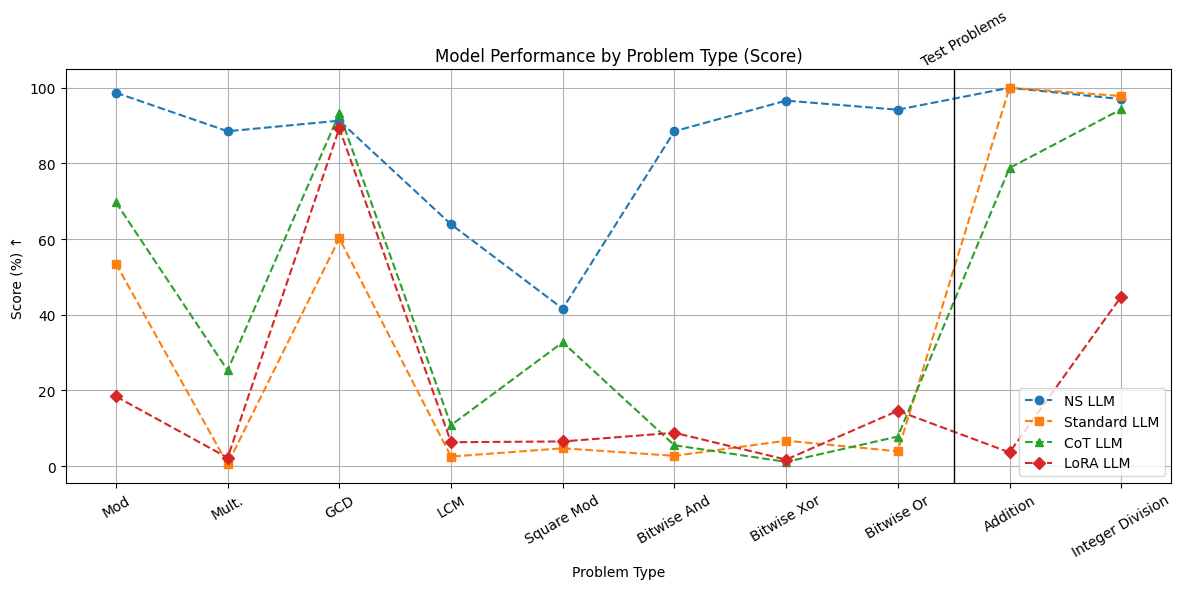

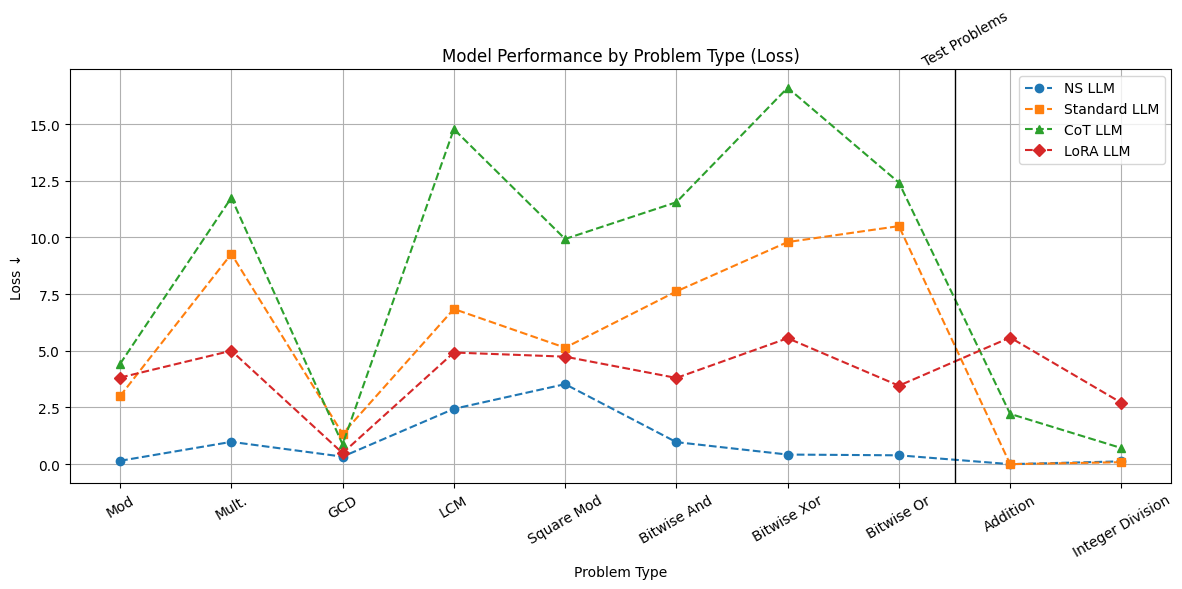

In [2]:
import matplotlib.pyplot as plt

# Problem types
problem_types = [
    "Mod", "Mult.", "GCD", "LCM", "Square Mod", "Bitwise And",
    "Bitwise Xor", "Bitwise Or", "Addition", "Integer Division"
]

separator_index = 8  # Index before test problems begin

models = ["NS LLM", "Standard LLM", "CoT LLM", "LoRA LLM"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
markers = ['o', 's', '^', 'D']
linestyle = '--'

scores = {
    "NS LLM":      [98.7, 88.5, 91.3, 63.9, 41.6, 88.5, 96.6, 94.2, 100.0, 97.0],
    "Standard LLM":[53.5,  0.5, 60.2,  2.5,  4.7,  2.7,  6.7,  3.9, 100.0, 97.8],
    "CoT LLM":     [69.7, 25.3, 93.2, 10.8, 32.7,  5.5,  1.1,  7.8,  78.8, 94.3],
    "LoRA LLM":    [18.4,  2.2, 89.3,  6.3,  6.5,  8.8,  1.7, 14.6,   3.6, 44.8],
}

losses = {
    "NS LLM":      [0.148, 0.984, 0.331, 2.440, 3.530, 0.971, 0.423, 0.390, 0.000, 0.124],
    "Standard LLM":[3.003, 9.276, 1.339, 6.846, 5.138, 7.621, 9.799,10.502, 0.000, 0.086],
    "CoT LLM":     [4.424,11.755, 0.874,14.778, 9.934,11.556,16.606,12.423, 2.218, 0.709],
    "LoRA LLM":    [3.819, 5.004, 0.488, 4.925, 4.742, 3.803, 5.557, 3.461, 5.587, 2.706],
}

def plot_metric(data_dict, ylabel, title):
    plt.figure(figsize=(12, 6))
    for i, model in enumerate(models):
        plt.plot(problem_types, data_dict[model], linestyle=linestyle,
                 marker=markers[i], label=model, color=colors[i])

    # Draw separator line
    plt.axvline(x=separator_index - 0.5, color='black', linestyle='-', linewidth=1)

    # Angled label
    ylim = plt.ylim()
    plt.text(separator_index, ylim[1], 'Test Problems', rotation=30,
             verticalalignment='bottom', horizontalalignment='right',
             fontsize=10, color='black')

    plt.xticks(rotation=30)
    plt.xlabel("Problem Type")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_metric(scores, "Score (%) ↑", "Model Performance by Problem Type (Score)")
plot_metric(losses, "Loss ↓", "Model Performance by Problem Type (Loss)")


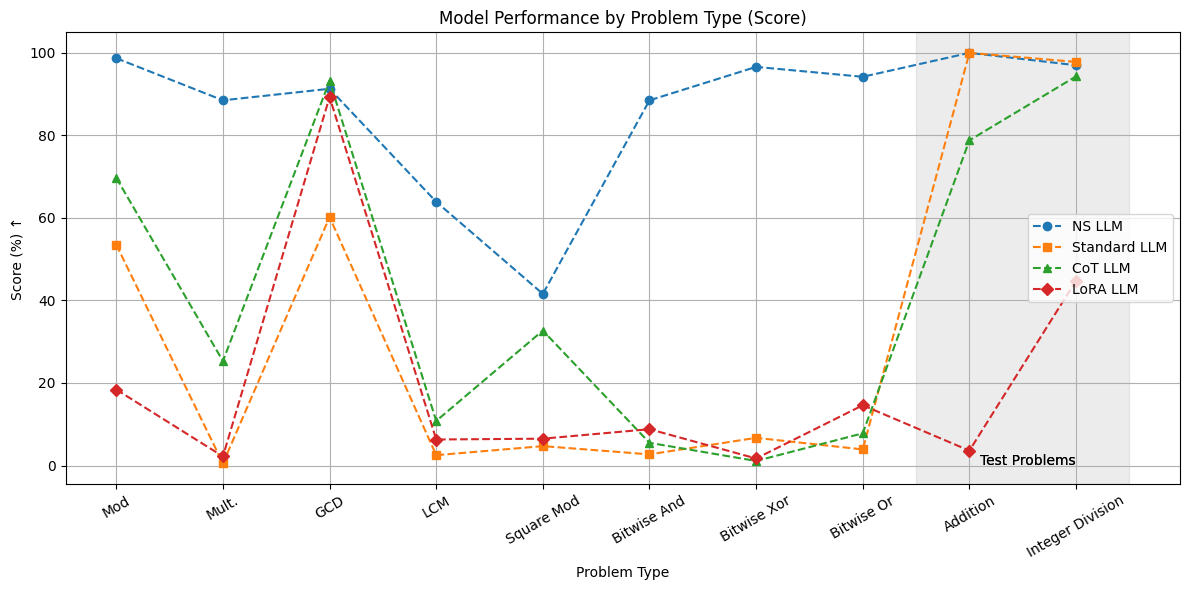

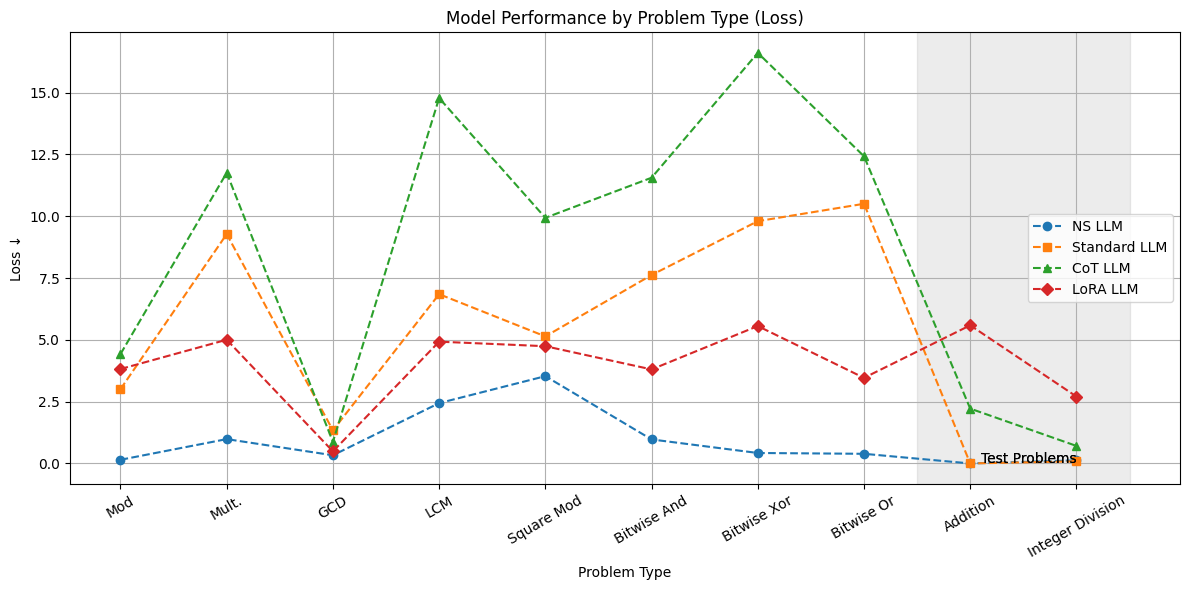

In [14]:
import matplotlib.pyplot as plt

# Problem types
problem_types = [
    "Mod", "Mult.", "GCD", "LCM", "Square Mod", "Bitwise And",
    "Bitwise Xor", "Bitwise Or", "Addition", "Integer Division"
]

separator_index = 8  # Index where test problems begin

models = ["NS LLM", "Standard LLM", "CoT LLM", "LoRA LLM"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
markers = ['o', 's', '^', 'D']
linestyle = '--'

scores = {
    "NS LLM":      [98.7, 88.5, 91.3, 63.9, 41.6, 88.5, 96.6, 94.2, 100.0, 97.0],
    "Standard LLM":[53.5,  0.5, 60.2,  2.5,  4.7,  2.7,  6.7,  3.9, 100.0, 97.8],
    "CoT LLM":     [69.7, 25.3, 93.2, 10.8, 32.7,  5.5,  1.1,  7.8,  78.8, 94.3],
    "LoRA LLM":    [18.4,  2.2, 89.3,  6.3,  6.5,  8.8,  1.7, 14.6,   3.6, 44.8],
}

losses = {
    "NS LLM":      [0.148, 0.984, 0.331, 2.440, 3.530, 0.971, 0.423, 0.390, 0.000, 0.124],
    "Standard LLM":[3.003, 9.276, 1.339, 6.846, 5.138, 7.621, 9.799,10.502, 0.000, 0.086],
    "CoT LLM":     [4.424,11.755, 0.874,14.778, 9.934,11.556,16.606,12.423, 2.218, 0.709],
    "LoRA LLM":    [3.819, 5.004, 0.488, 4.925, 4.742, 3.803, 5.557, 3.461, 5.587, 2.706],
}

def plot_metric(data_dict, ylabel, title):
    plt.figure(figsize=(12, 6))
    for i, model in enumerate(models):
        plt.plot(problem_types, data_dict[model], linestyle=linestyle,
                 marker=markers[i], label=model, color=colors[i])

    # Shade the test region
    plt.axvspan(separator_index - 0.5, len(problem_types) - 0.5, color='gray', alpha=0.15)
    plt.text(separator_index + 0.1, plt.ylim()[1]*.001, 'Test Problems',
             fontsize=10, color='black')
    plt.text(separator_index + 0.1, plt.ylim()[1]*.001, 'Test Problems',
             fontsize=10, color='black')

    plt.xticks(rotation=30)
    plt.xlabel("Problem Type")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_metric(scores, "Score (%) ↑", "Model Performance by Problem Type (Score)")
plot_metric(losses, "Loss ↓", "Model Performance by Problem Type (Loss)")


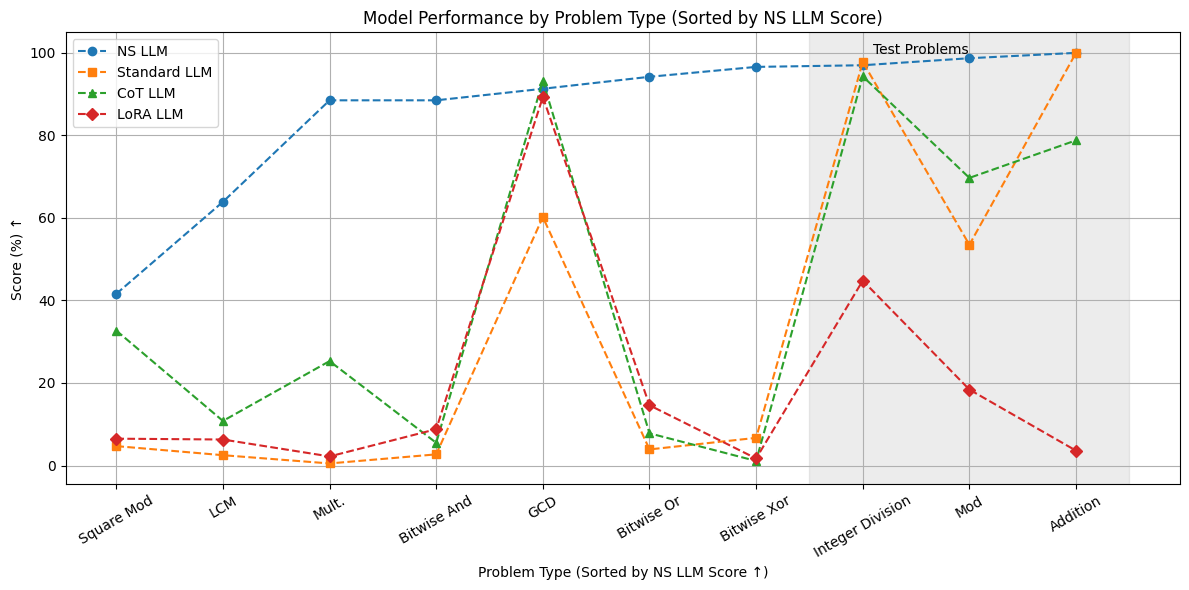

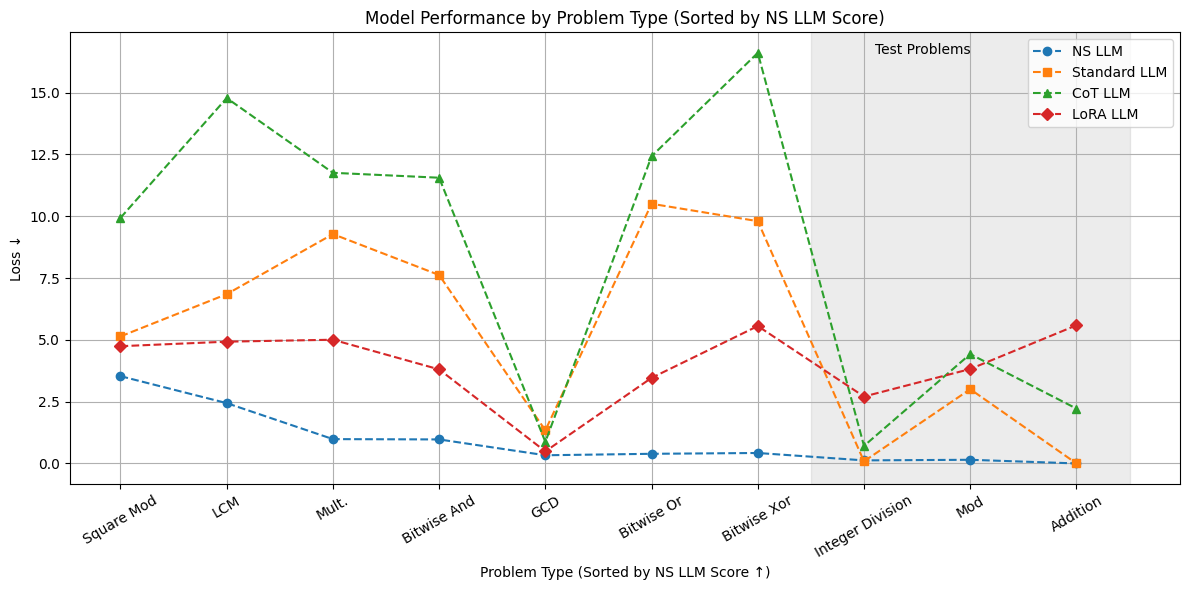

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Original problem types and NS LLM scores
problem_types = [
    "Mod", "Mult.", "GCD", "LCM", "Square Mod", "Bitwise And",
    "Bitwise Xor", "Bitwise Or", "Addition", "Integer Division"
]

ns_scores = [98.7, 88.5, 91.3, 63.9, 41.6, 88.5, 96.6, 94.2, 100.0, 97.0]

# Sort indices by increasing NS LLM score
sorted_indices = np.argsort(ns_scores)

# Apply sorting to problem types and all metric dictionaries
sorted_problem_types = [problem_types[i] for i in sorted_indices]

def reorder_dict(data_dict):
    return {model: [data_dict[model][i] for i in sorted_indices] for model in data_dict}

sorted_scores = reorder_dict({
    "NS LLM":      [98.7, 88.5, 91.3, 63.9, 41.6, 88.5, 96.6, 94.2, 100.0, 97.0],
    "Standard LLM":[53.5,  0.5, 60.2,  2.5,  4.7,  2.7,  6.7,  3.9, 100.0, 97.8],
    "CoT LLM":     [69.7, 25.3, 93.2, 10.8, 32.7,  5.5,  1.1,  7.8,  78.8, 94.3],
    "LoRA LLM":    [18.4,  2.2, 89.3,  6.3,  6.5,  8.8,  1.7, 14.6,   3.6, 44.8],
})

sorted_losses = reorder_dict({
    "NS LLM":      [0.148, 0.984, 0.331, 2.440, 3.530, 0.971, 0.423, 0.390, 0.000, 0.124],
    "Standard LLM":[3.003, 9.276, 1.339, 6.846, 5.138, 7.621, 9.799,10.502, 0.000, 0.086],
    "CoT LLM":     [4.424,11.755, 0.874,14.778, 9.934,11.556,16.606,12.423, 2.218, 0.709],
    "LoRA LLM":    [3.819, 5.004, 0.488, 4.925, 4.742, 3.803, 5.557, 3.461, 5.587, 2.706],
})

# Redefine the separator for shaded region (first test problem after sorting)
test_problem_names = {"Addition", "Integer Division"}
separator_index_sorted = next(i for i, pt in enumerate(sorted_problem_types) if pt in test_problem_names)

def plot_metric(data_dict, ylabel, title):
    plt.figure(figsize=(12, 6))
    for i, model in enumerate(models):
        plt.plot(sorted_problem_types, data_dict[model], linestyle=linestyle,
                 marker=markers[i], label=model, color=colors[i])

    # Shade test region
    plt.axvspan(separator_index_sorted - 0.5, len(problem_types) - 0.5, color='gray', alpha=0.15)
    plt.text(separator_index_sorted + 0.1, plt.ylim()[1]*0.95, 'Test Problems',
             fontsize=10, color='black')

    plt.xticks(rotation=30)
    plt.xlabel("Problem Type (Sorted by NS LLM Score ↑)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_metric(sorted_scores, "Score (%) ↑", "Model Performance by Problem Type (Sorted by NS LLM Score)")
plot_metric(sorted_losses, "Loss ↓", "Model Performance by Problem Type (Sorted by NS LLM Score)")


'../neurosymbolic_spider_poster.png'

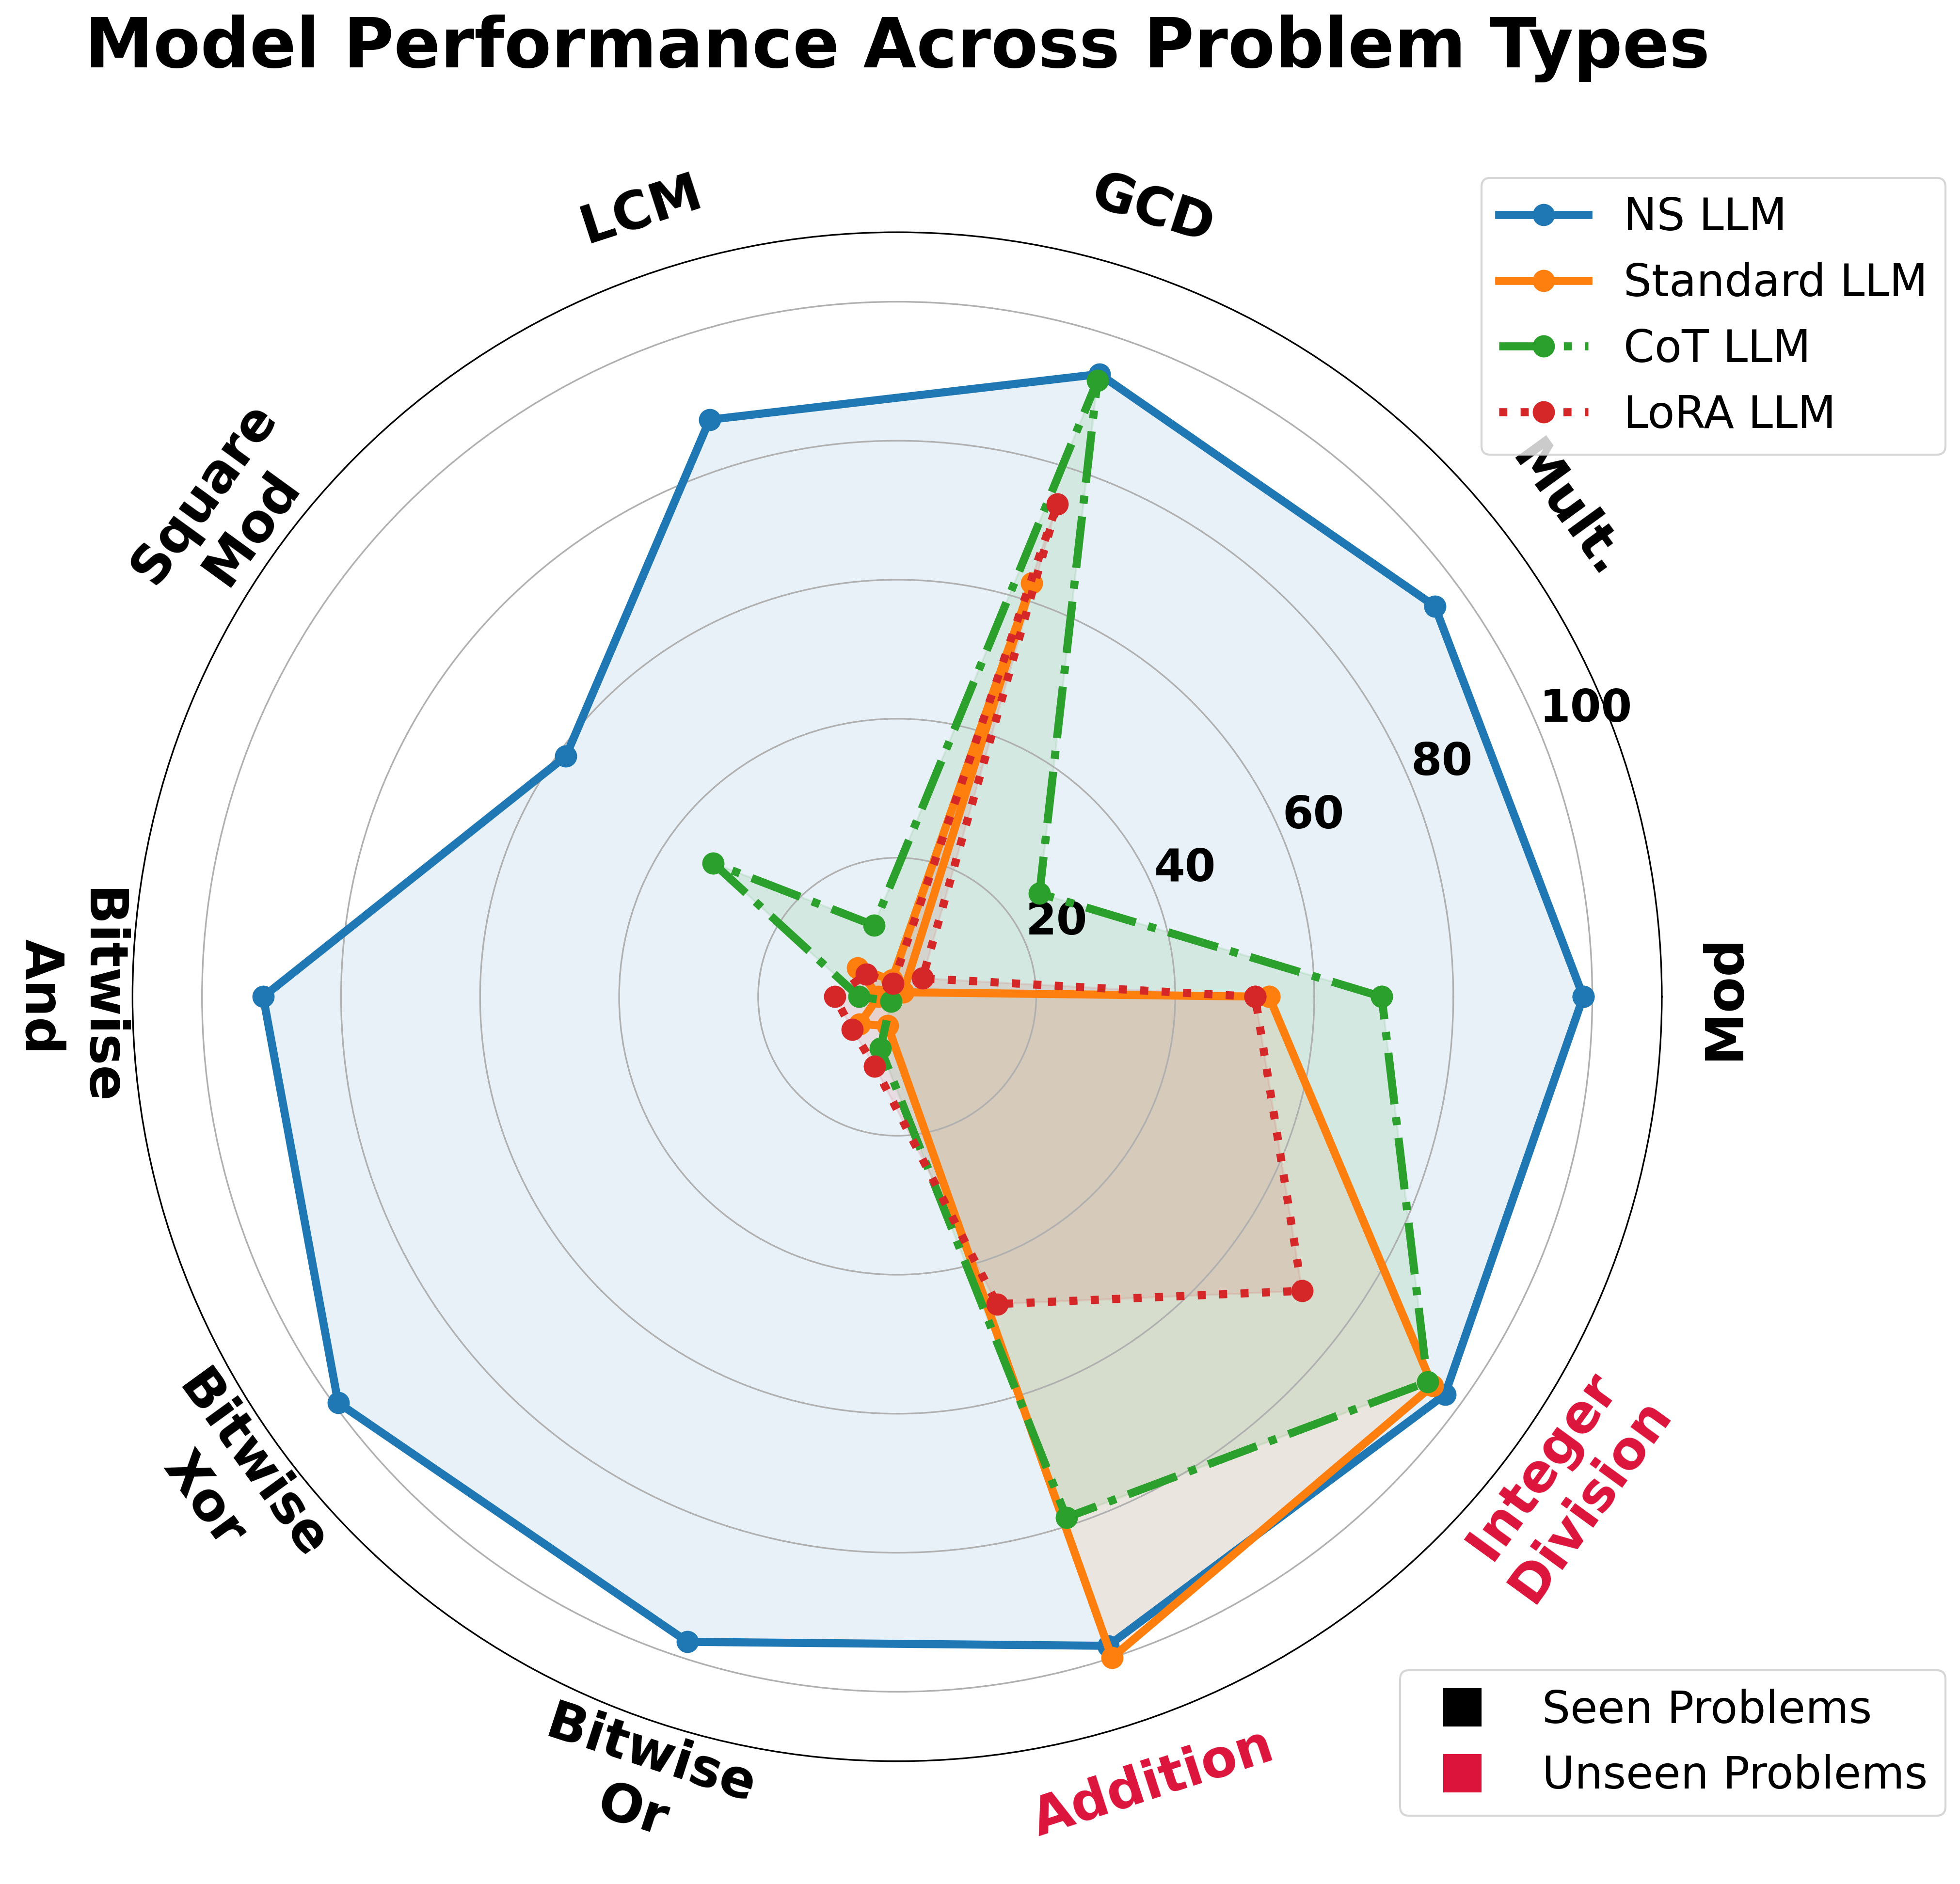

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Data
problem_types = [
    "Mod", "Mult.", "GCD", "LCM", "Square\nMod",
    "Bitwise\nAnd", "Bitwise\nXor", "Bitwise\nOr",
    "Addition", "Integer\nDivision"
]
scores = {
    "NS LLM":        [98.7, 95.6, 94.2, 87.3, 58.9, 91.2, 99.4, 97.6, 98.2, 97.4],
    "Standard LLM":  [53.5,  1.1, 62.6,  2.5,  7.0,  2.7,  6.7,  4.4,100.0, 95.2],
    "CoT LLM":       [69.7, 25.3, 93.2, 10.8, 32.7,  5.5,  1.1,  7.8, 78.8, 94.3],
    "LoRA LLM":      [51.5,  4.5, 74.5,  2.0,  5.5,  9.0,  8.0, 10.5, 46.5, 72.0],
}

test_indices = [8, 9]  # Addition, Integer Division

# Prepare angles
num_vars = len(problem_types)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Start plot
plt.figure(figsize=(16, 13), dpi=300)
ax = plt.subplot(111, polar=True)

# Radial ticks
plt.yticks([20, 40, 60, 80, 100], ["20", "40", "60", "80", "100"],
           fontsize=22, fontweight='bold')
plt.ylim(0, 110)
ax.set_xticks([])

# Helper for text rotation
def tangential_rotation(angle_rad):
    rot = np.degrees(angle_rad) + 90
    rot = (rot + 180) % 360 - 180
    if rot > 90:
        rot -= 180
    elif rot < -90:
        rot += 180
    return rot

# Place labels
label_radius = 119
for idx, (angle, label) in enumerate(zip(angles[:-1], problem_types)):
    color = 'crimson' if idx in test_indices else 'black'
    ax.text(angle, label_radius, label, size=26, weight='bold', color=color,
            ha='center', va='center',
            rotation=tangential_rotation(angle), rotation_mode='anchor')

# Plot model lines
color_map = {"NS LLM": "#1f77b4", "Standard LLM": "#ff7f0e", "CoT LLM": "#2ca02c", "LoRA LLM": "#d62728"}
linestyle_map = {"NS LLM": "-", "Standard LLM": "-", "CoT LLM": "-.", "LoRA LLM": ":"}

for model_name, model_scores in scores.items():
    values = model_scores + model_scores[:1]
    ax.plot(angles, values, label=model_name, linewidth=4, marker='o', markersize=10,
            color=color_map[model_name], linestyle=linestyle_map[model_name])
    ax.fill(angles, values, alpha=0.10, color=color_map[model_name])

plt.title("Model Performance Across Problem Types", size=34, weight='bold', y=1.10)

# Model legend (top‑right)
model_legend = ax.legend(loc='upper right', bbox_to_anchor=(1.20, 1.05),
                         fontsize=22, frameon=True)
ax.add_artist(model_legend)

# Problem-type legend (bottom‑right)
train_handle = Line2D([0], [0], marker='s', color='black', markersize=18,
                      linestyle='None', label='Seen Problems')
test_handle = Line2D([0], [0], marker='s', color='crimson', markersize=18,
                     linestyle='None', label='Unseen Problems')
ax.legend(handles=[train_handle, test_handle],
          loc='lower right', bbox_to_anchor=(1.20, -0.05),
          fontsize=22, frameon=True)

plt.tight_layout()

file_path = "../neurosymbolic_spider_poster.png"
plt.savefig(file_path, bbox_inches='tight', dpi=300)
file_path


'../neurosymbolic_bar_plot.png'

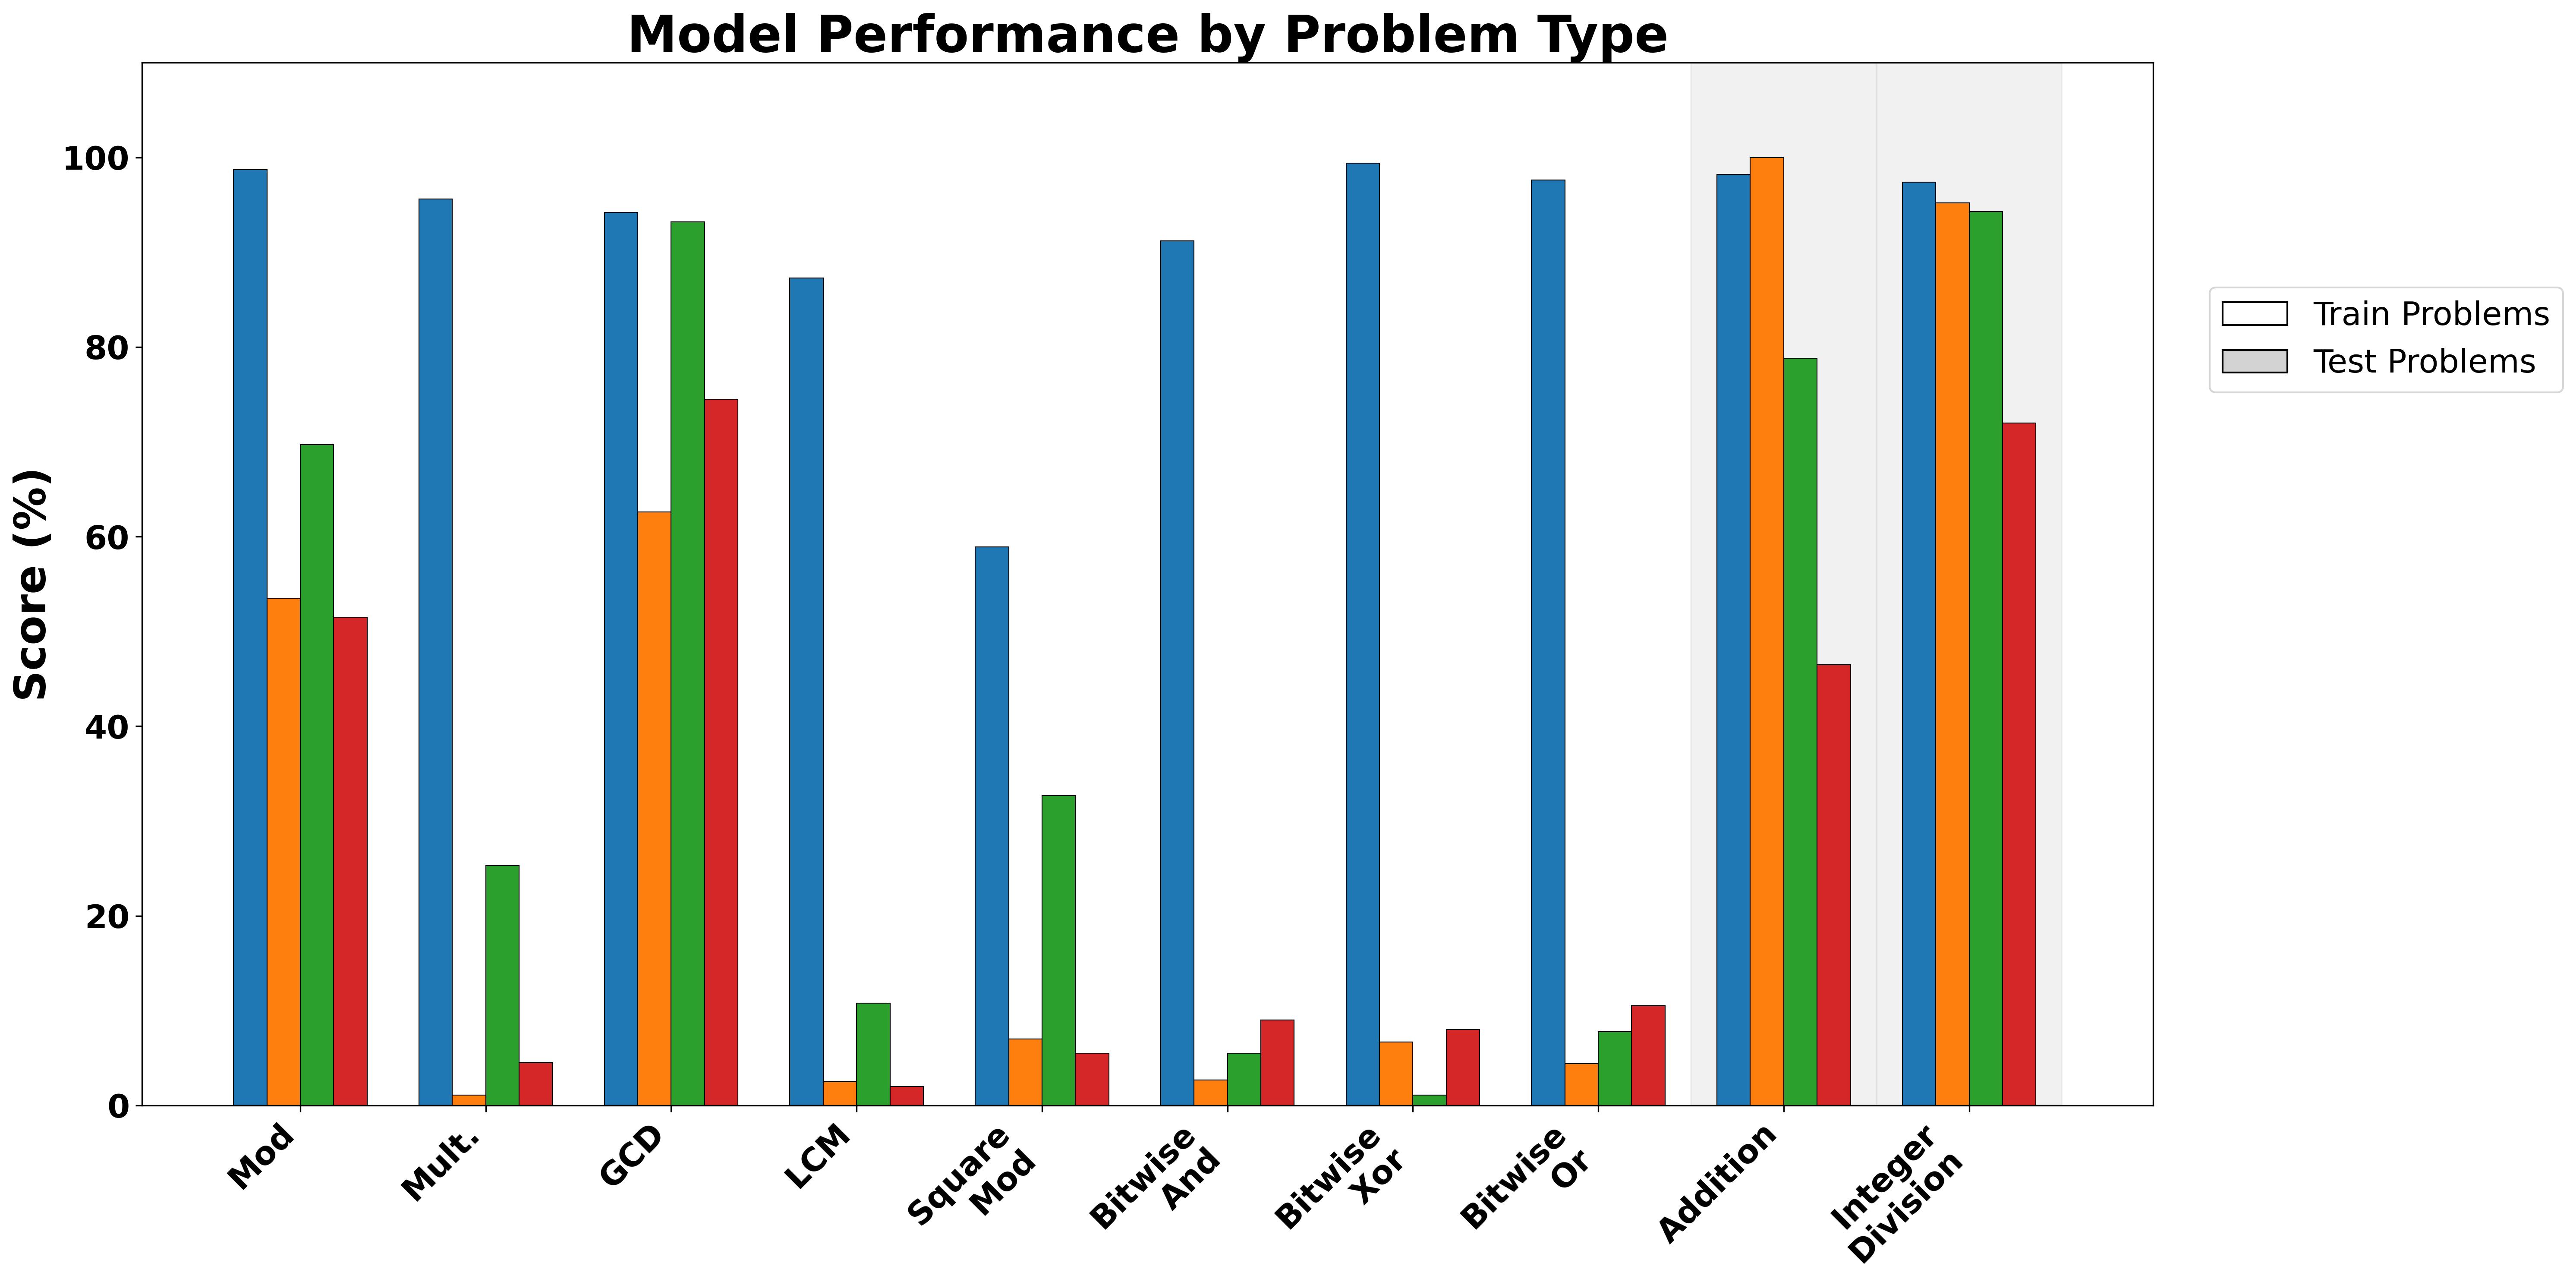

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Data
problem_types = [
    "Mod", "Mult.", "GCD", "LCM", "Square\nMod",
    "Bitwise\nAnd", "Bitwise\nXor", "Bitwise\nOr",
    "Addition", "Integer\nDivision"
]

scores = {
    "NS LLM":        [98.7, 95.6, 94.2, 87.3, 58.9, 91.2, 99.4, 97.6, 98.2, 97.4],
    "Standard LLM":  [53.5,  1.1, 62.6,  2.5,  7.0,  2.7,  6.7,  4.4,100.0, 95.2],
    "CoT LLM":       [69.7, 25.3, 93.2, 10.8, 32.7,  5.5,  1.1,  7.8, 78.8, 94.3],
    "LoRA LLM":      [51.5,  4.5, 74.5,  2.0,  5.5,  9.0,  8.0, 10.5, 46.5, 72.0],
}

models = list(scores.keys())
num_models = len(models)
num_categories = len(problem_types)
indices = np.arange(num_categories)

bar_width = 0.18
offsets = np.linspace(-1.5*bar_width, 1.5*bar_width, num_models)

# Colors
color_map = {"NS LLM": "#1f77b4", "Standard LLM": "#ff7f0e",
             "CoT LLM": "#2ca02c", "LoRA LLM": "#d62728"}

# Test categories
test_indices = [8, 9]  # Addition, Integer Division

plt.figure(figsize=(20, 10), dpi=300)
ax = plt.gca()

# Shade test categories
for idx in test_indices:
    ax.axvspan(idx-0.5, idx+0.5, color='lightgrey', alpha=0.3, zorder=0)

# Plot bars
for model_idx, model in enumerate(models):
    values = scores[model]
    ax.bar(indices + offsets[model_idx], values, bar_width,
           label=model, color=color_map[model], edgecolor='black', linewidth=0.5)

# Aesthetics
ax.set_ylabel("Score (%)", fontsize=24, fontweight='bold')
ax.set_xticks(indices)
ax.set_xticklabels(problem_types, fontsize=18, fontweight='bold', rotation=45, ha='right')
ax.set_ylim(0, 110)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18, fontweight='bold')

plt.title("Model Performance by Problem Type", fontsize=28, fontweight='bold')

# Legends
model_legend = ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=18, frameon=True)

# Train/Test legend
train_patch = Patch(facecolor='white', edgecolor='black', label='Train Problems')
test_patch = Patch(facecolor='lightgrey', edgecolor='black', label='Test Problems')
ax.legend(handles=[train_patch, test_patch], loc='upper left', bbox_to_anchor=(1.02, 0.8), fontsize=18, frameon=True)

plt.tight_layout()

file_path = "../neurosymbolic_bar_plot.png"
plt.savefig(file_path, bbox_inches='tight', dpi=300)
file_path
